<a href="https://colab.research.google.com/github/mafe1307/analisis-datos-fac-equipo-4/blob/main/Calidad_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===========================
# calidad_de_datos.py
# ===========================
import numpy as np
import pandas as pd
import re

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from scipy.stats import chi2

In [ ]:
# Leer los datos
df = pd.read_excel('/content/JEFAB_2024.xlsx')
print("=== INFORMACIÓN GENERAL ===")
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")


=== INFORMACIÓN GENERAL ===
Total de registros: 6423
Total de columnas: 231


Cargando Excel...
Filas: 6,423 | Columnas: 231
Escaneando columnas de texto para detectar mojibake...

===== REPORTE DE PROBLEMAS DE ENCODING (MOJIBAKE) =====

- Columnas de texto analizadas: 66
- Columnas con posibles problemas: 28
- Celdas sospechosas en total: 51020

>>> Artefactos globales más frecuentes (top 20):
    'Ã': 18094, 'Ã“': 15846, 'Ã‘': 7218, 'Ã‰': 6074, 'Â ': 4022, 'Ã': 3952, 'Ã¡': 1489, 'Ã­': 150, 'Ã³': 90, 'Ã±': 39, 'Ã©': 24, 'Ãº': 12

>>> Detalle por columna (mostrando hasta 20):

 1. [METODO_RESOLUCION_PROBLEMAS_FAMILIAR]  celdas sospechosas: 6195  (96.45%)
    Artefactos más comunes: 'Ã': 6195
    Ejemplos (original → sugerido) [máx 3]:
      - 1. DIÃLOGO  →  DIÁLOGO

 2. [FRECUENCIA_VISITA_FAMILIAR]  celdas sospechosas: 6062  (94.38%)
    Artefactos más comunes: 'Ã‘': 6062
    Ejemplos (original → sugerido) [máx 3]:
      - 1. MAS DE 5 VECES AL AÃ‘O  →  MAS DE 5 VECES AL AO
      - 2. 1 VEZ AL AÃ‘O  →  1 VEZ AL AO
      - 3. 3 VECES AL AÃ‘O  →  3 VECES AL AO


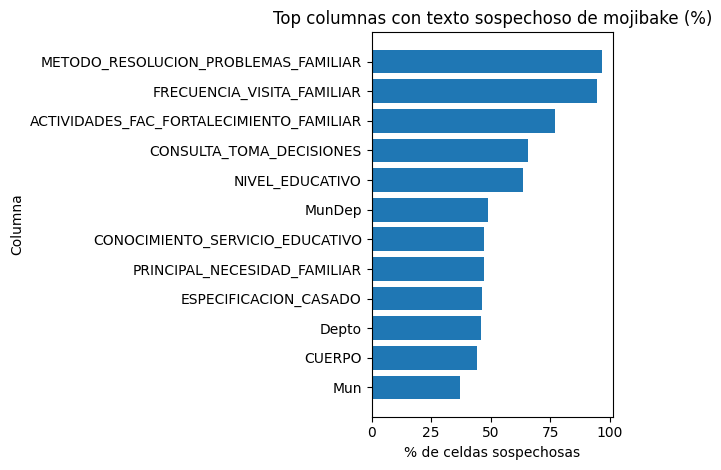

/tmp/ipython-input-3947138084.py:233: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3947138084.py:233: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


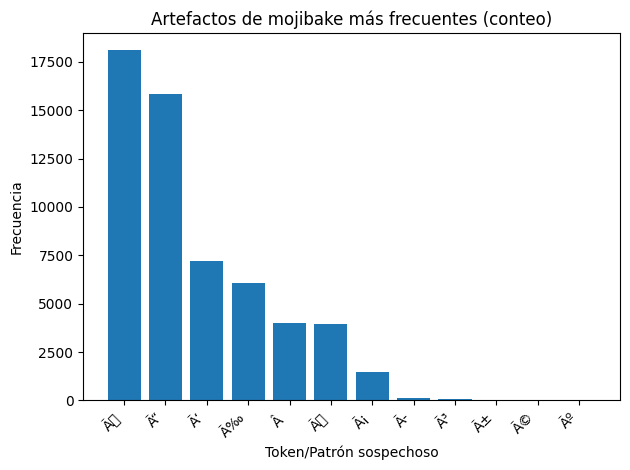

/tmp/ipython-input-3947138084.py:250: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()


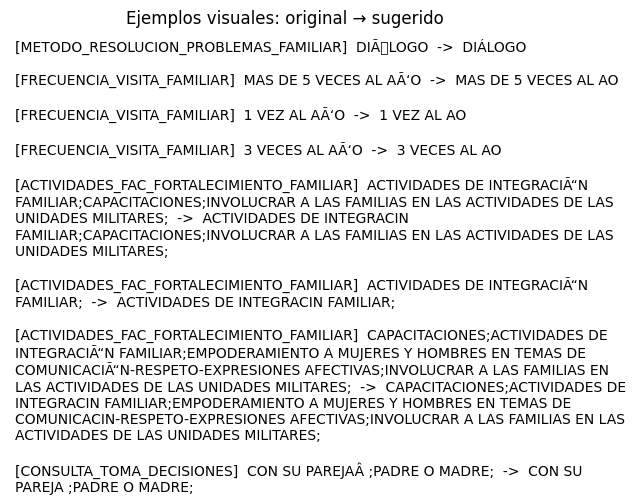

No hay figuras para mostrar.


In [ ]:
# DETECCIÓN DE ENCODING
"""
encoding_report_visual.py
"""

import re
import sys
import pandas as pd
from collections import Counter

# ========= CONFIGURACIÓN =========
RUTA_XLSX   = "/content/JEFAB_2024.xlsx"         # <-- cambia si es necesario
NOMBRE_HOJA = "Data_Initial_FAC_1689243593_0"     # <-- o usa sheet_name=0
MAX_COLS_MOSTRAR = 20                           # nº de columnas a detallar en consola
MAX_EJEMPLOS_COL = 3                               # nº de ejemplos por columna
GUARDAR_SI_NO_GUI = False                          # si no hay GUI: guardar PNGs? (False por defecto)

# ========= BACKEND MATPLOTLIB ROBUSTO =========
import os
import matplotlib

def _set_matplotlib_backend():
    """Selecciona un backend adecuado según el entorno."""
    # ¿Jupyter / IPython inline?
    try:
        get_ipython  # type: ignore
        matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
        return "inline"
    except Exception:
        pass

    # Backends con ventana (GUI)
    for bk in ("TkAgg", "Qt5Agg", "MacOSX"):
        try:
            matplotlib.use(bk, force=True)
            return bk
        except Exception:
            continue

    # Fallback sin GUI
    matplotlib.use("Agg", force=True)
    return "Agg"

BACKEND = _set_matplotlib_backend()

import matplotlib.pyplot as plt  # importa después de fijar backend

def mostrar_o_guardar_figuras(prefix="fig_mojibake_", guardar_si_no_gui=False):
    """
    - Si hay backend GUI: muestra ventanas y bloquea hasta cerrar.
    - Si es inline (notebook): ya se muestran.
    - Si no hay GUI y 'guardar_si_no_gui' es True: guarda PNGs numerados.
    """
    fignums = plt.get_fignums()
    if not fignums:
        print("No hay figuras para mostrar.")
        return

    if BACKEND in ("TkAgg", "Qt5Agg", "MacOSX"):
        plt.show(block=True)
    elif BACKEND == "inline":
        # En notebook se verán automáticamente
        pass
    else:
        if guardar_si_no_gui:
            for i, num in enumerate(fignums, start=1):
                fig = plt.figure(num)
                out = f"{prefix}{i:02d}.png"
                fig.savefig(out, bbox_inches="tight")
                print(f"[Sin GUI] Figura guardada: {out}")
        else:
            print("[Sin GUI] No hay backend gráfico disponible. "
                  "Ejecuta en un entorno con GUI o cambia GUARDAR_SI_NO_GUI=True para guardar PNGs.")

# ========= DETECCIÓN DE MOJIBAKE =========
# Patrón general de mojibake (Ã, Â, combinaciones Ã., Â., ¿, ¡, �, emojis rotos ðŸ.)
MOJIBAKE_PATTERN = re.compile(r"[ÃÂ�]|Ã.|Â.|¿|¡|ðŸ|�")
# Para conteo de artefactos individuales/bigramas
MOJIBAKE_TOKEN_PATTERN = re.compile(r"(?:Ã.|Â.|ðŸ.)|[�¿¡]")

def looks_mojibake(s: str) -> bool:
    """True si la cadena contiene artefactos típicos de mojibake."""
    if s is None:
        return False
    return bool(MOJIBAKE_PATTERN.search(str(s)))

def tokenize_mojibake(s: str):
    """Lista de 'tokens' mojibake encontrados (para conteos)."""
    if s is None:
        return []
    return MOJIBAKE_TOKEN_PATTERN.findall(str(s))

def candidate_fix(text: str) -> str:
    """
    Vista previa de corrección SIN aplicar cambios al DataFrame.
    Intenta UTF-8 leído como Latin-1 y la ruta inversa; escoge la de menos artefactos.
    """
    if text is None:
        return text
    t = str(text)
    try:
        cand1 = t.encode("latin1", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        cand1 = t
    try:
        cand2 = t.encode("utf-8", errors="ignore").decode("latin1", errors="ignore")
    except Exception:
        cand2 = t
    c0 = len(MOJIBAKE_PATTERN.findall(t))
    c1 = len(MOJIBAKE_PATTERN.findall(cand1))
    c2 = len(MOJIBAKE_PATTERN.findall(cand2))
    best = t
    if c1 < c0 and c1 <= c2:
        best = cand1
    elif c2 < c0 and c2 < c1:
        best = cand2
    return best

def escanear_encoding(df: pd.DataFrame, max_ejemplos=3):
    """
    Recorre columnas object y devuelve:
      - resumen_columnas: lista de dicts con métricas por columna y ejemplos
      - global_tokens: Counter con frecuencias de artefactos en todo el DF
      - meta: métricas globales
    """
    resumen_columnas = []
    global_tokens = Counter()

    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    total_obj = len(obj_cols)
    total_cols_sospechosas = 0
    total_celdas_sospechosas = 0

    for col in obj_cols:
        s = df[col].astype(str)
        mask = s.notna() & s.apply(looks_mojibake)
        n_bad = int(mask.sum())
        if n_bad == 0:
            continue

        total_cols_sospechosas += 1
        total_celdas_sospechosas += n_bad
        pct = round(n_bad / len(s) * 100, 3)

        col_tokens = Counter()
        for val in s[mask]:
            toks = tokenize_mojibake(val)
            col_tokens.update(toks)
            global_tokens.update(toks)

        uniques = s[mask].dropna().unique().tolist()[:max_ejemplos]
        ejemplos = [(val, candidate_fix(val)) for val in uniques]

        resumen_columnas.append({
            "columna": col,
            "celdas_sospechosas": n_bad,
            "pct_sospechosas": pct,
            "artefactos_top": col_tokens.most_common(10),
            "ejemplos": ejemplos
        })

    resumen_columnas.sort(key=lambda r: (r["pct_sospechosas"], r["celdas_sospechosas"]), reverse=True)

    meta = {
        "total_columnas_texto": total_obj,
        "columnas_con_mojibake": total_cols_sospechosas,
        "celdas_sospechosas_total": total_celdas_sospechosas
    }
    return resumen_columnas, global_tokens, meta

# ========= REPORTE EN CONSOLA =========
def imprimir_reporte(resumen_columnas, global_tokens, meta, max_cols=20, max_ejemplos=3):
    print("\n===== REPORTE DE PROBLEMAS DE ENCODING (MOJIBAKE) =====\n")
    print(f"- Columnas de texto analizadas: {meta['total_columnas_texto']}")
    print(f"- Columnas con posibles problemas: {meta['columnas_con_mojibake']}")
    print(f"- Celdas sospechosas en total: {meta['celdas_sospechosas_total']}\n")

    if meta["columnas_con_mojibake"] == 0:
        print("No se detectaron celdas sospechosas. ✅")
        return

    print(">>> Artefactos globales más frecuentes (top 20):")
    if global_tokens:
        top = global_tokens.most_common(20)
        print("    " + ", ".join([f"'{tok}': {cnt}" for tok, cnt in top]))
    else:
        print("    (sin artefactos tokenizables)")
    print()

    print(f">>> Detalle por columna (mostrando hasta {max_cols}):\n")
    for i, r in enumerate(resumen_columnas[:max_cols], start=1):
        print(f"{i:>2}. [{r['columna']}]  celdas sospechosas: {r['celdas_sospechosas']}  ({r['pct_sospechosas']}%)")
        if r["artefactos_top"]:
            arts = ", ".join([f"'{tok}': {cnt}" for tok, cnt in r["artefactos_top"]])
            print(f"    Artefactos más comunes: {arts}")
        else:
            print("    Artefactos más comunes: (no tokenizables)")
        if r["ejemplos"]:
            print(f"    Ejemplos (original → sugerido) [máx {max_ejemplos}]:")
            for j, (orig, sug) in enumerate(r["ejemplos"][:max_ejemplos], start=1):
                print(f"      - {j}. {orig}  →  {sug}")
        print()

# ========= GRÁFICOS =========
def graficos_encoding(df):
    """Genera 3 figuras: top columnas afectadas, artefactos frecuentes y ejemplos visuales."""
    resumen_columnas, global_tokens, _ = escanear_encoding(df, max_ejemplos=MAX_EJEMPLOS_COL)

    # Figura 1: Top columnas afectadas por porcentaje
    if resumen_columnas:
        topK = min(12, len(resumen_columnas))
        cols = [r["columna"] for r in resumen_columnas[:topK]][::-1]
        vals = [r["pct_sospechosas"] for r in resumen_columnas[:topK]][::-1]
        plt.figure()
        plt.barh(cols, vals)
        plt.title("Top columnas con texto sospechoso de mojibake (%)")
        plt.xlabel("% de celdas sospechosas")
        plt.ylabel("Columna")
        plt.tight_layout()
        plt.show()

    # Figura 2: Artefactos globales más frecuentes
    if global_tokens:
        top_tokens = global_tokens.most_common(15)
        tokens = [t for t, _ in top_tokens]
        counts = [c for _, c in top_tokens]
        plt.figure()
        plt.bar(range(len(tokens)), counts)
        plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
        plt.title("Artefactos de mojibake más frecuentes (conteo)")
        plt.xlabel("Token/Patrón sospechoso")
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

    # Figura 3: Ejemplos visuales (texto)
    if resumen_columnas:
        ejemplos_total = []
        for r in resumen_columnas[:5]:
            for (orig, sug) in r["ejemplos"]:
                ejemplos_total.append((r["columna"], orig, sug))
        ejemplos_total = ejemplos_total[:8]
        if ejemplos_total:
            lines = [f"[{col}]  {orig}  ->  {sug}" for col, orig, sug in ejemplos_total]
            display_text = "\n\n".join(lines)
            plt.figure()
            plt.axis("off")
            plt.title("Ejemplos visuales: original → sugerido")
            plt.text(0.01, 0.98, display_text, va="top", ha="left", wrap=True, fontsize=10)
            plt.tight_layout()
            plt.show()

# ========= MAIN =========
def main():
    print("Cargando Excel...")
    df = pd.read_excel(RUTA_XLSX, sheet_name=NOMBRE_HOJA)
    print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")

    print("Escaneando columnas de texto para detectar mojibake...")
    resumen_columnas, global_tokens, meta = escanear_encoding(df, max_ejemplos=MAX_EJEMPLOS_COL)
    imprimir_reporte(resumen_columnas, global_tokens, meta,
                     max_cols=MAX_COLS_MOSTRAR, max_ejemplos=MAX_EJEMPLOS_COL)

    # Generar figuras
    graficos_encoding(df)
    # Mostrar (o guardar si no hay GUI y así se indica)
    mostrar_o_guardar_figuras(guardar_si_no_gui=GUARDAR_SI_NO_GUI)

if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print("ERROR:", e, file=sys.stderr)
        sys.exit(1)

In [ ]:
# --- Corrección y reparación de encoding ---
# Assuming detect_mojibake_counts and fix_dataframe_encoding are defined elsewhere
try:
    sospechosas = detect_mojibake_counts(df)  # cuenta celdas con mojibake por columna
    print("Columnas con mojibake (top 15):", dict(list(sospechosas.items())[:15]))
    df, reporte_encoding = fix_dataframe_encoding(df, columns=None)
    print("Reporte de reparación de encoding (muestras):")
    print({k: v for i, (k, v) in enumerate(reporte_encoding.items()) if i < 10})
except NameError as e:
    print(f"Error: {e}. Make sure 'detect_mojibake_counts' and 'fix_dataframe_encoding' functions are defined.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

    # --- Verificación rápida y guardado de la base reparada ---
import os

# (opcional) conteo de celdas que siguen sospechosas
restantes = detect_mojibake_counts(df)
print(f"Celdas sospechosas remanentes (debería ser 0 si todo salió bien): {sum(restantes.values()) if restantes else 0}")

# Rutas de salida tomando como base la ubicación del archivo original
base_dir  = os.path.dirname(ruta) or "."
base_name = os.path.splitext(os.path.basename(ruta))[0]
out_xlsx  = os.path.join(base_dir, f"{base_name}_encoding_fixed.xlsx")
out_csv   = os.path.join(base_dir, f"{base_name}_encoding_fixed.csv")

# Guardar Excel (si el entorno lo permite) y CSV
try:
    df.to_excel(out_xlsx, index=False)
    print(f"[OK] Excel limpio guardado en: {out_xlsx}")
except Exception as e:
    print(f"[AVISO] No se pudo escribir Excel ({e}). Continúo con CSV.")

df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[OK] CSV limpio guardado en: {out_csv}")


Columnas con mojibake (top 15): {}
Reporte de reparación de encoding (muestras):
{}
Celdas sospechosas remanentes (debería ser 0 si todo salió bien): 0
[OK] Excel limpio guardado en: /content/JEFAB_2024_encoding_fixed.xlsx
[OK] CSV limpio guardado en: /content/JEFAB_2024_encoding_fixed.csv


In [ ]:
# IMPUTACIÓN Y ACP
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
try:
    from sklearn.impute import KNNImputer
    _HAS_KNN = True
except Exception:
    _HAS_KNN = False

# =========================
# CONFIGURACIÓN
# =========================
# Si ya guardaste una base con encoding corregido, apunta a esa ruta:
RUTA_XLSX   = "/content/JEFAB_2024_encoding_fixed.xlsx"  # cambia si usas otra
# Si no existe, usa el original + nombre de hoja:
HOJA        = "Data_Initial_FAC_1689243593_0"

VAR_OBJ     = 0.80   # varianza acumulada objetivo para decidir nº de PCs
MAX_IT_MICE = 6      # iteraciones de MICE (menos = más estable/rápido)
N_NEAREST   = 20     # nº máx. de predictores adicionales completos en MICE
SAVE_FILES  = True   # guardar Excel con datos imputados + scores + loadings

OUT_XLSX    = "/content/JEFAB_2024_imputed_PCA.xlsx"  # salida si SAVE_FILES=True

# =========================
# FUNCIONES
# =========================
def imputacion_mice_fast_safe(df, vars_numericas=None, *,
                              max_it=8, random_state=42,
                              fill_for_all_nan=0.0, n_nearest=20):
    """
    Imputación numérica robusta:
      - Imputa solo columnas numéricas con NA; añade hasta n_nearest predictores completos.
      - Maneja ±Inf, columnas todo-NaN y con <2 datos (pre-relleno).
      - Fallback: IterativeImputer -> KNNImputer -> SimpleImputer.
      - Restaura dtype entero redondeando.
    Retorna: df_imputado, reporte_dict, imputer_usado
    """
    if vars_numericas is None:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        num_cols = [c for c in vars_numericas if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No hay columnas numéricas para imputar.")

    X = df[num_cols].copy().replace([np.inf, -np.inf], np.nan)
    cols_with_na = [c for c in X.columns if X[c].isna().any()]
    if not cols_with_na:
        return df.copy(), {"cols_imputadas": [], "predictores_adicionales": [],
                           "cols_all_nan_preRellenadas": [], "cols_baja_muestra_preRellenadas": [],
                           "fallback": None, "error_iterative": None, "error_knn": None}, None

    # Pre-rellenos
    all_nan_cols = [c for c in cols_with_na if X[c].isna().all()]
    low_obs_cols = [c for c in cols_with_na if X[c].notna().sum() < 2]
    for c in all_nan_cols:
        X[c] = fill_for_all_nan
    for c in low_obs_cols:
        med = X[c].median()
        if np.isnan(med): med = fill_for_all_nan
        X[c] = X[c].fillna(med)

    # Predictores completos más informativos (por varianza)
    complete_cols = [c for c in num_cols if not X[c].isna().any()]
    complete_cols_sorted = sorted(complete_cols, key=lambda c: X[c].var(), reverse=True)[:max(n_nearest, 1)]

    used_cols = list(dict.fromkeys(cols_with_na + complete_cols_sorted))
    X_used = X[used_cols].copy()

    orig_int_cols = [c for c in used_cols if pd.api.types.is_integer_dtype(df[c].dtype)]

    reporte = {
        "cols_imputadas": cols_with_na,
        "predictores_adicionales": [c for c in used_cols if c not in cols_with_na],
        "cols_all_nan_preRellenadas": all_nan_cols,
        "cols_baja_muestra_preRellenadas": low_obs_cols,
        "fallback": None,
        "error_iterative": None,
        "error_knn": None
    }

    # IterativeImputer “rápido”
    try:
        imputer = IterativeImputer(
            max_iter=max_it,
            random_state=random_state,
            sample_posterior=False,
            imputation_order="ascending",
            n_nearest_features=min(n_nearest, len(used_cols)-1) if len(used_cols) > 1 else None,
            initial_strategy="median"
        )
        X_imp = imputer.fit_transform(X_used)
    except Exception as e1:
        reporte["error_iterative"] = repr(e1)
        if _HAS_KNN:
            try:
                imputer = KNNImputer(n_neighbors=5, weights="uniform")
                X_imp = imputer.fit_transform(X_used)
                reporte["fallback"] = "KNNImputer"
            except Exception as e2:
                reporte["error_knn"] = repr(e2)
                simputer = SimpleImputer(strategy="median")
                X_imp = simputer.fit_transform(X_used)
                imputer = simputer
                reporte["fallback"] = "SimpleImputer"
        else:
            simputer = SimpleImputer(strategy="median")
            X_imp = simputer.fit_transform(X_used)
            imputer = simputer
            reporte["fallback"] = "SimpleImputer"

    df_out = df.copy()
    df_out[used_cols] = X_imp
    # Restaurar enteros
    for c in orig_int_cols:
        df_out[c] = np.round(df_out[c]).astype(df[c].dtype, copy=False)

    return df_out, reporte, imputer

def pca_por_varianza(df_num, var_obj=0.80, scale=True):
    """Estandariza (opcional), ajusta PCA y elige nº de componentes por varianza acumulada."""
    X = df_num.copy()
    if scale:
        scaler = StandardScaler()
        Z = scaler.fit_transform(X.values)
    else:
        scaler = None
        Z = X.values

    pca = PCA().fit(Z)
    evr = pca.explained_variance_ratio_
    evr_cum = np.cumsum(evr)
    ncomp = int(np.argmax(evr_cum >= var_obj) + 1)

    # Re-ajustar con ncomp y construir salidas
    pca_k = PCA(n_components=ncomp).fit(Z)
    scores = pca_k.transform(Z)
    loadings = pca_k.components_.T  # (p x k)

    cols = X.columns.tolist()
    pc_cols = [f"PC{i+1}" for i in range(ncomp)]

    scores_df = pd.DataFrame(scores, index=X.index, columns=pc_cols)
    loadings_df = pd.DataFrame(loadings, index=cols, columns=pc_cols)

    resumen = pd.DataFrame({
        "PC": pc_cols,
        "var_exp": evr[:ncomp],
        "var_exp_cum": evr_cum[:ncomp]
    })
    return {
        "scaler": scaler,
        "pca": pca_k,
        "n_componentes": ncomp,
        "resumen_var": resumen,
        "scores": scores_df,
        "loadings": loadings_df
    }

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    # Cargar base
    if os.path.exists(RUTA_XLSX):
        df = pd.read_excel(RUTA_XLSX)
        fuente = RUTA_XLSX
    else:
        # Correct the path for the original file as well
        df = pd.read_excel("/content/JEFAB_2024.xlsx", sheet_name=HOJA)
        fuente = "/content/JEFAB_2024.xlsx"


    # Elegir columnas numéricas
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) < 2:
        raise ValueError("Se requieren al menos 2 columnas numéricas para PCA.")

    # Quitar columnas con varianza ~0 (constantes)
    var0 = [c for c in num_cols if df[c].dropna().nunique() <= 1]
    if var0:
        print(f"Aviso: se excluyen {len(var0)} columnas constantes (var≈0).")
    num_cols = [c for c in num_cols if c not in var0]

    # IMPUTACIÓN
    df_imp, rep_mice, _ = imputacion_mice_fast_safe(
        df, vars_numericas=num_cols,
        max_it=MAX_IT_MICE, n_nearest=N_NEAREST, random_state=42
    )

    # PCA (sobre variables numéricas imputadas)
    pca_res = pca_por_varianza(df_imp[num_cols], var_obj=VAR_OBJ, scale=True)

    # MERGE: agregar PCs a la base imputada
    df_imp_scores = pd.concat([df_imp, pca_res["scores"]], axis=1)

    # SALIDA / RESUMEN
    print("\n=== IMPUTACIÓN ===")
    print({k: (len(v) if isinstance(v, list) else v) for k, v in rep_mice.items()})

    print("\n=== PCA (por varianza acumulada) ===")
    print(f"Variables usadas: {len(num_cols)} | Componentes seleccionados: {pca_res['n_componentes']}")
    print(pca_res["resumen_var"].round(4).to_string(index=False))

    print("\nEjemplo de cargas (top 10 por |PC1|):")
    print(pca_res["loadings"]["PC1"].abs().sort_values(ascending=False).head(10).to_string())

    # Guardar Excel opcionalmente
    if SAVE_FILES:
        try:
            with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
                df_imp_scores.to_excel(writer, sheet_name="data_imputed", index=False)
                pca_res["loadings"].to_excel(writer, sheet_name="pca_loadings")
                pca_res["resumen_var"].to_excel(writer, sheet_name="pca_var")
            print(f"\n[OK] Archivo escrito: {OUT_XLSX}")
        except Exception as e:
            # Fallback a CSVs
            base = os.path.splitext(OUT_XLSX)[0]
            df_imp_scores.to_csv(base + "_data_imputed.csv", index=False)
            pca_res["loadings"].to_csv(base + "_pca_loadings.csv")
            pca_res["resumen_var"].to_csv(base + "_pca_var.csv", index=False)
            print(f"\n[AVISO] No se pudo escribir Excel ({e}). Se guardaron CSVs en {base}_*.csv")


=== IMPUTACIÓN ===
{'cols_imputadas': 7, 'predictores_adicionales': 20, 'cols_all_nan_preRellenadas': 0, 'cols_baja_muestra_preRellenadas': 0, 'fallback': None, 'error_iterative': None, 'error_knn': None}

=== PCA (por varianza acumulada) ===
Variables usadas: 165 | Componentes seleccionados: 76
  PC  var_exp  var_exp_cum
 PC1   0.0574       0.0574
 PC2   0.0509       0.1083
 PC3   0.0421       0.1504
 PC4   0.0296       0.1800
 PC5   0.0255       0.2056
 PC6   0.0242       0.2298
 PC7   0.0189       0.2487
 PC8   0.0172       0.2659
 PC9   0.0162       0.2822
PC10   0.0161       0.2982
PC11   0.0147       0.3129
PC12   0.0135       0.3264
PC13   0.0130       0.3394
PC14   0.0129       0.3523
PC15   0.0122       0.3645
PC16   0.0119       0.3764
PC17   0.0114       0.3878
PC18   0.0112       0.3990
PC19   0.0109       0.4099
PC20   0.0108       0.4208
PC21   0.0104       0.4312
PC22   0.0098       0.4410
PC23   0.0097       0.4507
PC24   0.0091       0.4598
PC25   0.0089       0.4687


In [ ]:
# -*- coding: utf-8 -*-
"""
recodificar_imputar_pca.py

Pasos:
1) Recodifica pares *_SI / *_NO / *_NO_RESP|NO_RES -> <STEM>_BIN (1=SI, 0=NO, NaN=NO_RESP)
2) Imputa medianas en numéricas con NA
3) Estandariza y corre PCA hasta alcanzar varianza objetivo (por defecto 80%)
4) Guarda CSVs (y Excel opcional)
"""

import os
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# =========================
# CONFIGURACIÓN
# =========================
RUTA_XLSX    = "/content/JEFAB_2024_encoding_fixed.xlsx"  # usa la base limpia si ya la tienes
NOMBRE_HOJA  = "Data_Initial_FAC_1689243593_0"                    # se usa si RUTA_XLSX no existe
VAR_OBJ      = 0.80                                               # 0.70 si quieres menos componentes
GUARDAR_EXCEL= False                                              # True para intentar Excel además de CSV
OUT_BASENAME = "/content/JEFAB_2024_recoded_imputed_PCA"         # prefijo de salida

# =========================
# UTILIDADES
# =========================
def cargar_base(ruta, hoja):
    if os.path.exists(ruta):
        df = pd.read_excel(ruta)
        src = ruta
    else:
        df = pd.read_excel("/content/JEFAB_2024.xlsx", sheet_name=hoja)
        src = "/content/JEFAB_2024.xlsx"
    return df, src

_pat_suffix = re.compile(r"^(?P<stem>.+?)_(?P<suf>SI|NO|NO_RESP|NO_RES)$", re.IGNORECASE)

def truthy_series(s: pd.Series) -> pd.Series:
    """True si es 'verdadero' (numérico>0 o texto {si,sí,true,yes,1,x,y})."""
    if s is None:
        return pd.Series(False, index=s.index if s is not None else [])
    if s.dtype.kind in "biufc":
        return s.astype(float).fillna(0) > 0
    t = s.astype(str).str.strip().str.lower()
    return t.isin(["si", "sí", "true", "t", "1", "x", "y", "yes"])

def recodificar_si_no(df: pd.DataFrame) -> (pd.DataFrame, pd.DataFrame):
    """
    Crea <stem>_BIN:
      - 1 si *_SI verdadero
      - 0 si *_NO verdadero
      - NaN si *_NO_RESP/NO_RES verdadero
      - Conflicto (SI & NO) -> NaN
    Elimina *_SI, *_NO, *_NO_RESP/NO_RES originales.
    Devuelve df_modificado y auditoría.
    """
    groups = defaultdict(dict)
    for c in df.columns:
        m = _pat_suffix.match(str(c))
        if m:
            groups[m.group("stem")][m.group("suf").upper()] = c

    audit_rows = []
    df_rec = df.copy()

    for stem, cols in groups.items():
        col_SI = cols.get("SI")
        col_NO = cols.get("NO")
        col_NR = cols.get("NO_RESP") or cols.get("NO_RES")
        if not (col_SI or col_NO or col_NR):
            continue

        new_col = f"{stem}_BIN"
        if new_col in df_rec.columns:
            base = new_col; k = 2
            while new_col in df_rec.columns:
                new_col = f"{base}_{k}"
                k += 1

        new = pd.Series(np.nan, index=df_rec.index, dtype=float)

        si_mask = truthy_series(df_rec[col_SI]) if col_SI else pd.Series(False, index=df_rec.index)
        no_mask = truthy_series(df_rec[col_NO]) if col_NO else pd.Series(False, index=df_rec.index)
        nr_mask = truthy_series(df_rec[col_NR]) if col_NR else pd.Series(False, index=df_rec.index)

        conflict = si_mask & no_mask

        # Asignaciones
        new[si_mask & ~conflict] = 1.0
        new[no_mask & ~conflict & new.isna()] = 0.0
        # NO_RESP / NO_RES -> forzar NaN
        new[nr_mask] = np.nan
        # Conflictos -> NaN
        new[conflict] = np.nan

        df_rec[new_col] = new

        to_drop = [c for c in (col_SI, col_NO, col_NR) if c is not None]
        df_rec.drop(columns=to_drop, inplace=True, errors="ignore")

        audit_rows.append({
            "grupo_stem": stem,
            "SI_col": col_SI,
            "NO_col": col_NO,
            "NO_RESP_col": col_NR,
            "n_unos": int((new == 1).sum()),
            "n_ceros": int((new == 0).sum()),
            "n_na": int(new.isna().sum()),
            "n_conflictos_SI_y_NO": int(conflict.sum()),
            "n_cols_eliminadas": len(to_drop),
            "nueva_columna": new_col
        })

    audit_df = pd.DataFrame(audit_rows).sort_values(
        ["n_conflictos_SI_y_NO", "n_na", "grupo_stem"],
        ascending=[False, False, True]
    )

    return df_rec, audit_df

def imputar_medianas(df: pd.DataFrame) -> (pd.DataFrame, dict):
    """Imputa mediana solo en columnas numéricas con NA; quita constantes antes de PCA."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # quitar constantes
    num_cols = [c for c in num_cols if df[c].dropna().nunique() > 1]
    cols_with_na = [c for c in num_cols if df[c].isna().any()]

    if cols_with_na:
        simputer = SimpleImputer(strategy="median")
        df.loc[:, cols_with_na] = simputer.fit_transform(df[cols_with_na])

    rep = {"num_cols_totales": len(num_cols), "cols_imputadas": len(cols_with_na)}
    return df, rep, num_cols

def pca_por_varianza(df_num: pd.DataFrame, var_obj=0.80, scale=True):
    """Estandariza y ajusta PCA. Selecciona n componentes para alcanzar var_obj de varianza acumulada."""
    X = df_num.copy()
    if scale:
        Z = StandardScaler().fit_transform(X.values)
    else:
        Z = X.values

    pca_full = PCA().fit(Z)
    evr = pca_full.explained_variance_ratio_
    evr_cum = np.cumsum(evr)
    ncomp = int(np.argmax(evr_cum >= var_obj) + 1)

    pca_k = PCA(n_components=ncomp).fit(Z)
    scores = pca_k.transform(Z)
    loadings = pca_k.components_.T

    cols = X.columns.tolist()
    pc_cols = [f"PC{i+1}" for i in range(ncomp)]
    scores_df = pd.DataFrame(scores, index=X.index, columns=pc_cols)
    loadings_df = pd.DataFrame(loadings, index=cols, columns=pc_cols)
    resumen_var = pd.DataFrame({"PC": pc_cols, "var_exp": evr[:ncomp], "var_exp_cum": evr_cum[:ncomp]})

    return {"n_componentes": ncomp, "scores": scores_df, "loadings": loadings_df, "resumen_var": resumen_var}

def guardar_salidas(basepath: str, df_out: pd.DataFrame, loadings: pd.DataFrame, resumen_var: pd.DataFrame, audit: pd.DataFrame, guardar_excel=False):
    csv_data = basepath + "_data_imputed.csv"
    csv_load = basepath + "_pca_loadings.csv"
    csv_var  = basepath + "_pca_var.csv"
    csv_aud  = basepath + "_recoding_audit.csv"

    df_out.to_csv(csv_data, index=False)
    loadings.to_csv(csv_load)
    resumen_var.to_csv(csv_var, index=False)
    audit.to_csv(csv_aud, index=False)

    if guardar_excel:
        try:
            import openpyxl  # noqa: F401
            with pd.ExcelWriter(basepath + ".xlsx", engine="openpyxl") as writer:
                df_out.to_excel(writer, sheet_name="data_imputed", index=False)
                loadings.to_excel(writer, sheet_name="pca_loadings")
                resumen_var.to_excel(writer, sheet_name="pca_var", index=False)
                audit.to_excel(writer, sheet_name="recoding_audit", index=False)
            print(f"[OK] Excel escrito: {basepath}.xlsx")
        except Exception as e:
            print(f"[AVISO] No se pudo escribir Excel ({e}). CSVs listos:")
            print(" -", csv_data)
            print(" -", csv_load)
            print(" -", csv_var)
            print(" -", csv_aud)
    else:
        print("[OK] CSVs escritos:")
        print(" -", csv_data)
        print(" -", csv_load)
        print(" -", csv_var)
        print(" -", csv_aud)

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    # 1) Cargar
    df, fuente = cargar_base(RUTA_XLSX, NOMBRE_HOJA)
    print(f"Fuente de datos: {fuente} | Filas={len(df):,} Cols={df.shape[1]}")

    # 2) Recodificar SI/NO/NO_RESP -> BIN
    df_rec, audit_df = recodificar_si_no(df)
    print(f"Recodificación: se crearon {audit_df.shape[0]} columnas *_BIN y se eliminaron las dummies originales.")

    # 3) Imputar medianas en numéricas con NA (y quitar constantes para PCA)
    df_imp, rep_imp, num_cols = imputar_medianas(df_rec)
    print(f"Imputación: {rep_imp['cols_imputadas']} columna(s) imputadas por mediana. Numéricas usadas para PCA: {len(num_cols)}")

    # 4) PCA por varianza objetivo
    pca_res = pca_por_varianza(df_imp[num_cols], var_obj=VAR_OBJ, scale=True)
    print(f"PCA: componentes seleccionados para alcanzar {int(VAR_OBJ*100)}% varianza = {pca_res['n_componentes']}")

    # 5) Unir scores al DataFrame e imprimir resumen corto
    df_out = pd.concat([df_imp, pca_res["scores"]], axis=1)

    print("\nTop 10 |cargas| en PC1:")
    print(pca_res["loadings"]["PC1"].abs().sort_values(ascending=False).head(10).to_string())

    # 6) Guardar
    guardar_salidas(
        OUT_BASENAME,
        df_out,
        pca_res["loadings"],
        pca_res["resumen_var"].round(4),
        audit_df,
        guardar_excel=GUARDAR_EXCEL
    )

Fuente de datos: /content/JEFAB_2024_encoding_fixed.xlsx | Filas=6,423 Cols=231
Recodificación: se crearon 16 columnas *_BIN y se eliminaron las dummies originales.
Imputación: 14 columna(s) imputadas por mediana. Numéricas usadas para PCA: 144
PCA: componentes seleccionados para alcanzar 80% varianza = 79

Top 10 |cargas| en PC1:
MIEMB_COMP_VIV_HIJOS                    0.316293
MIEMB_COMP_VIV_ESPOSO                   0.312571
MIEMB_COMP_VIV_NO RESP                  0.309904
BENEFICIO_BARRACA_UNIDAD_NO_RESPONDE    0.309904
VIVE_EN_ARRIENDO_NO_RESPONDE            0.309904
BENEFICIO_VIVIENDA_FISCAL_BIN           0.262064
BENEFICIO_BARRACA_UNIDAD_BIN            0.196509
SERV_EDU_UBICACION                      0.194441
VIVE_EN_ARRIENDO_BIN                    0.192844
SERV_EDU_NO_RESPONDE                    0.190989
[OK] CSVs escritos:
 - /content/JEFAB_2024_recoded_imputed_PCA_data_imputed.csv
 - /content/JEFAB_2024_recoded_imputed_PCA_pca_loadings.csv
 - /content/JEFAB_2024_recoded_impute

In [ ]:
# -*- coding: utf-8 -*-
"""
recodificar_imputar_pca_v2.py

Mejora clave: recodificación robusta de *_SI / *_NO / *_NO_RESP* tolerante a
variantes: espacios, acentos y sufijos como "NO RESP", "NO_RESPONDE",
"NO_RESPUESTA", etc.
"""

import os, re, unicodedata
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# =========================
# CONFIGURACIÓN
# =========================
RUTA_XLSX    = "/content/JEFAB_2024_encoding_fixed.xlsx"          # <- ajusta si usas otra ruta
NOMBRE_HOJA  = "Data_Initial_FAC_1689243593_0"                    # se usa si RUTA_XLSX no existe
VAR_OBJ      = 0.80                                               # p. ej. 0.70 si quieres menos PCs
GUARDAR_EXCEL= False                                              # True para intentar Excel además de CSV
OUT_BASENAME = "/content/JEFAB_2024_recoded_imputed_PCA_v2"       # prefijo de salida

# =========================
# UTILIDADES
# =========================
def cargar_base(ruta, hoja):
    if os.path.exists(ruta):
        df = pd.read_excel(ruta)
        src = ruta
    else:
        df = pd.read_excel("/content/JEFAB_2024.xlsx", sheet_name=hoja)
        src = "/content/JEFAB_2024.xlsx"
    return df, src

def _strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def normalizar_nombre(col: str) -> str:
    """
    Normaliza nombres de columnas: mayúsculas, sin acentos,
    no alfanumérico -> '_', colapsa '_' múltiples.
    """
    s = str(col).strip()
    s = _strip_accents(s).upper()
    s = re.sub(r"[^A-Z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

# Sufijos permitidos para 'no respuesta' (normalizados)
NORESP_TOKENS = {
    "NO_RESP", "NO_RES", "NORESP", "NO_RESPONDE", "NO_RESPUESTA",
    "NO_RESPONSE", "SIN_RESPUESTA", "NO_RESP.", "NR", "NRESP", "NO_RESPONDIÓ", "NO_RESPONDIO"
}
# También consideramos "SI" y "NO"
SI_TOKEN = "SI"
NO_TOKEN = "NO"

def partir_stem_sufijo(norm_col: str):
    """
    Separa <stem> y <sufijo> del nombre normalizado.
    Devuelve (stem, suf) si hay patrón *_<SUF>, si no, (None, None).
    """
    m = re.match(r"^(?P<stem>.+)_(?P<suf>[A-Z0-9]+)$", norm_col)
    if not m:
        return None, None
    return m.group("stem"), m.group("suf")

def truthy_series(s: pd.Series) -> pd.Series:
    """True si es 'verdadero' (numérico>0 o texto {si,sí,true,yes,1,x,y})."""
    if s is None:
        return pd.Series(False, index=s.index if s is not None else [])
    if s.dtype.kind in "biufc":
        return s.astype(float).fillna(0) > 0
    t = s.astype(str).str.strip().str.lower()
    return t.isin(["si", "sí", "true", "t", "1", "x", "y", "yes"])

def recodificar_pares_si_no_robusto(df: pd.DataFrame):
    """
    Crea <stem>_BIN a partir de pares *_SI / *_NO / *_NORESP* (tolerante a variantes).
    Elimina las columnas originales del grupo. Devuelve df_modificado + auditoría.
    """
    # Mapa de nombre normalizado -> nombre original
    norm2orig = {normalizar_nombre(c): c for c in df.columns}
    # Agrupar por stem normalizado
    grupos = defaultdict(dict)
    for norm, orig in norm2orig.items():
        stem, suf = partir_stem_sufijo(norm)
        if stem is None:
            continue
        if suf == SI_TOKEN:
            grupos[stem]["SI"] = orig
        elif suf == NO_TOKEN:
            grupos[stem]["NO"] = orig
        elif suf in NORESP_TOKENS:
            grupos[stem]["NO_RESP"] = orig  # agrupamos todas las variantes como NO_RESP

    df_rec = df.copy()
    audit_rows = []

    for stem, cols in grupos.items():
        col_SI = cols.get("SI")
        col_NO = cols.get("NO")
        col_NR = cols.get("NO_RESP")

        # si no hay al menos una de SI/NO/NR, no armamos grupo
        if not (col_SI or col_NO or col_NR):
            continue

        new_col = stem + "_BIN"
        # Evitar colisiones si ya existe
        if new_col in {normalizar_nombre(c): c for c in df_rec.columns}:
            # asegurar nombre único manteniendo sufijo _BIN_k en el DataFrame real
            base = stem + "_BIN"
            k = 2
            real_new_col = base
            while real_new_col in df_rec.columns:
                real_new_col = f"{base}_{k}"
                k += 1
        else:
            real_new_col = stem + "_BIN"

        new = pd.Series(np.nan, index=df_rec.index, dtype=float)
        si_mask = truthy_series(df_rec[col_SI]) if col_SI else pd.Series(False, index=df_rec.index)
        no_mask = truthy_series(df_rec[col_NO]) if col_NO else pd.Series(False, index=df_rec.index)
        nr_mask = truthy_series(df_rec[col_NR]) if col_NR else pd.Series(False, index=df_rec.index)

        conflict = si_mask & no_mask

        # Asignación
        new[si_mask & ~conflict] = 1.0
        new[no_mask & ~conflict & new.isna()] = 0.0
        new[nr_mask] = np.nan           # no respuesta -> NA
        new[conflict] = np.nan          # conflicto -> NA

        df_rec[real_new_col] = new

        # Eliminar columnas originales del grupo
        to_drop = [c for c in (col_SI, col_NO, col_NR) if c is not None]
        df_rec.drop(columns=to_drop, inplace=True, errors="ignore")

        audit_rows.append({
            "grupo_stem_norm": stem,
            "SI_col": col_SI,
            "NO_col": col_NO,
            "NO_RESP_col": col_NR,
            "n_unos": int((new == 1).sum()),
            "n_ceros": int((new == 0).sum()),
            "n_na": int(new.isna().sum()),
            "n_conflictos_SI_y_NO": int(conflict.sum()),
            "n_cols_eliminadas": len(to_drop),
            "nueva_columna": real_new_col
        })

    audit_df = pd.DataFrame(audit_rows).sort_values(
        ["n_conflictos_SI_y_NO","n_na","grupo_stem_norm"],
        ascending=[False, False, True]
    )
    return df_rec, audit_df

def imputar_medianas_y_cols_para_pca(df: pd.DataFrame):
    """Imputa medianas solo en columnas numéricas con NA y devuelve la lista final de columnas para PCA (sin constantes)."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # quitar constantes
    num_cols = [c for c in num_cols if df[c].dropna().nunique() > 1]
    cols_with_na = [c for c in num_cols if df[c].isna().any()]
    if cols_with_na:
        simputer = SimpleImputer(strategy="median")
        df.loc[:, cols_with_na] = simputer.fit_transform(df[cols_with_na])
    rep = {"num_cols_totales": len(num_cols), "cols_imputadas": len(cols_with_na)}
    return df, rep, num_cols

def pca_por_varianza(df_num: pd.DataFrame, var_obj=0.80, scale=True):
    X = df_num.copy()
    Z = StandardScaler().fit_transform(X.values) if scale else X.values
    pca_full = PCA().fit(Z)
    evr = pca_full.explained_variance_ratio_
    evr_cum = np.cumsum(evr)
    ncomp = int(np.argmax(evr_cum >= var_obj) + 1)
    pca_k = PCA(n_components=ncomp).fit(Z)
    scores = pca_k.transform(Z)
    loadings = pca_k.components_.T
    cols = X.columns.tolist()
    pc_cols = [f"PC{i+1}" for i in range(ncomp)]
    scores_df = pd.DataFrame(scores, index=X.index, columns=pc_cols)
    loadings_df = pd.DataFrame(loadings, index=cols, columns=pc_cols)
    resumen_var = pd.DataFrame({"PC": pc_cols, "var_exp": evr[:ncomp], "var_exp_cum": evr_cum[:ncomp]})
    return {"n_componentes": ncomp, "scores": scores_df, "loadings": loadings_df, "resumen_var": resumen_var}

def guardar_salidas(basepath: str, df_out: pd.DataFrame, loadings: pd.DataFrame, resumen_var: pd.DataFrame, audit: pd.DataFrame, guardar_excel=False):
    csv_data = basepath + "_data_imputed.csv"
    csv_load = basepath + "_pca_loadings.csv"
    csv_var  = basepath + "_pca_var.csv"
    csv_aud  = basepath + "_recoding_audit.csv"
    df_out.to_csv(csv_data, index=False)
    loadings.to_csv(csv_load)
    resumen_var.to_csv(csv_var, index=False)
    audit.to_csv(csv_aud, index=False)
    if guardar_excel:
        try:
            import openpyxl  # noqa: F401
            with pd.ExcelWriter(basepath + ".xlsx", engine="openpyxl") as writer:
                df_out.to_excel(writer, sheet_name="data_imputed", index=False)
                loadings.to_excel(writer, sheet_name="pca_loadings")
                resumen_var.to_excel(writer, sheet_name="pca_var", index=False)
                audit.to_excel(writer, sheet_name="recoding_audit", index=False)
            print(f"[OK] Excel escrito: {basepath}.xlsx")
        except Exception as e:
            print(f"[AVISO] No se pudo escribir Excel ({e}). CSVs listos:")
            print(" -", csv_data); print(" -", csv_load); print(" -", csv_var); print(" -", csv_aud)
    else:
        print("[OK] CSVs escritos:"); print(" -", csv_data); print(" -", csv_load); print(" -", csv_var); print(" -", csv_aud)

# =========================
# MAIN
# =========================
if __name__ == "__main__":
    # 1) Cargar
    df, fuente = cargar_base(RUTA_XLSX, NOMBRE_HOJA)
    print(f"Fuente de datos: {fuente} | Filas={len(df):,} Cols={df.shape[1]}")

    # 2) Recodificación robusta
    df_rec, audit_df = recodificar_pares_si_no_robusto(df)
    print(f"Recodificación robusta: se crearon {audit_df.shape[0]} columnas *_BIN y se eliminaron sus dummies.")

    # 3) Imputación mediana + columnas para PCA
    df_imp, rep_imp, num_cols = imputar_medianas_y_cols_para_pca(df_rec)
    print(f"Imputación: {rep_imp['cols_imputadas']} columna(s) imputadas. Numéricas usadas para PCA: {len(num_cols)}")

    # 4) PCA por varianza objetivo
    pca_res = pca_por_varianza(df_imp[num_cols], var_obj=VAR_OBJ, scale=True)
    df_out = pd.concat([df_imp, pca_res["scores"]], axis=1)
    print(f"PCA: componentes para alcanzar {int(VAR_OBJ*100)}% varianza = {pca_res['n_componentes']}")

    # 5) Top 10 |cargas| en PC1 (diagnóstico rápido)
    print("\nTop 10 |cargas| en PC1 (post-recodificación robusta):")
    print(pca_res["loadings"]["PC1"].abs().sort_values(ascending=False).head(10).to_string())

    # 6) Guardar
    guardar_salidas(
        OUT_BASENAME,
        df_out,
        pca_res["loadings"],
        pca_res["resumen_var"].round(4),
        audit_df,
        guardar_excel=GUARDAR_EXCEL
    )


Fuente de datos: /content/JEFAB_2024_encoding_fixed.xlsx | Filas=6,423 Cols=231
Recodificación robusta: se crearon 15 columnas *_BIN y se eliminaron sus dummies.
Imputación: 14 columna(s) imputadas. Numéricas usadas para PCA: 150
PCA: componentes para alcanzar 80% varianza = 78

Top 10 |cargas| en PC1 (post-recodificación robusta):
DEP_MIEMBRO_FAMILIAR_DISCAPACITADO_NO_RES    0.340894
MIEM_FAM_DISC_BIN                            0.340894
PERT_PROG_DISCAP_MIEMB_FAM_NO_RESP           0.340894
APOYO_FAM_DISC_NO_RESP                       0.340894
APOYO_FAM_DISC_EMOC                          0.292452
APOYO_FAM_DISC_MAT                           0.281235
APOYO_FAM_DISC_COG                           0.231312
APOYO_FAM_DISC_INSTRU                        0.230512
DEP_MIEMBRO_FAMILIAR_DISCAPACITADO_BIN       0.176610
DISC_NO_RESP                                 0.129859
[OK] CSVs escritos:
 - /content/JEFAB_2024_recoded_imputed_PCA_v2_data_imputed.csv
 - /content/JEFAB_2024_recoded_imputed_PCA_

In [ ]:
# exportar_xlsx_robusto.py
import os, sys, subprocess
import pandas as pd

# ---- Nombres base (no cambies si usaste mis scripts previos) ----
DATA_NAME  = "JEFAB_2024_recoded_imputed_PCA_data_imputed.csv"
LOAD_NAME  = "JEFAB_2024_recoded_imputed_PCA_pca_loadings.csv"
VAR_NAME   = "JEFAB_2024_recoded_imputed_PCA_pca_var.csv"
AUDIT_NAME = "JEFAB_2024_recoded_imputed_PCA_recoding_audit.csv"
BLOCKS_SUM = os.path.join("pca_bloques", "pca_bloques_resumen.csv")

# ---- Dónde buscar (auto-detección) ----
BASE_DIRS = ["/content", "/mnt/data", "."]  # se chequean en este orden

def first_existing(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

def find_input_paths():
    # intentamos en cada base dir
    candidates = []
    for base in BASE_DIRS:
        candidates.append((
            os.path.join(base, DATA_NAME),
            os.path.join(base, LOAD_NAME),
            os.path.join(base, VAR_NAME),
            os.path.join(base, AUDIT_NAME),
            os.path.join(base, BLOCKS_SUM)
        ))
    # elegir el primer set donde al menos existe DATA
    for (data_p, load_p, var_p, aud_p, blk_p) in candidates:
        if os.path.exists(data_p):
            return data_p, load_p, var_p, aud_p, blk_p
    return None, None, None, None, None

DATA_CSV, LOAD_CSV, VAR_CSV, AUDIT_CSV, BLOCKS_SUM_CSV = find_input_paths()
if DATA_CSV is None:
    raise FileNotFoundError(
        "No encontré el CSV principal (data_imputed). "
        "Asegúrate de haber corrido el script que genera los CSVs primero."
    )

# salida en la misma carpeta que DATA_CSV
OUT_XLSX = os.path.join(os.path.dirname(DATA_CSV), "JEFAB_2024_final.xlsx")

# ---- Intenta usar openpyxl; si no está, instala; si falla, prueba xlsxwriter ----
ENGINE = None
try:
    import openpyxl  # noqa: F401
    ENGINE = "openpyxl"
except Exception:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])
        import openpyxl  # noqa: F401
        ENGINE = "openpyxl"
    except Exception:
        try:
            import xlsxwriter  # noqa: F401
            ENGINE = "xlsxwriter"
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter", "-q"])
            import xlsxwriter  # noqa: F401
            ENGINE = "xlsxwriter"

print({"engine": ENGINE})

# ---- Lectura segura ----
def read_csv_safe(path, **kw):
    if path and os.path.exists(path):
        try:
            return pd.read_csv(path, low_memory=False, **kw)
        except Exception as e:
            print({"warning": f"No pude leer {path} con kwargs {kw}. Reintento sin kwargs.", "detalle": repr(e)})
            return pd.read_csv(path, low_memory=False)
    return pd.DataFrame()

df_out   = read_csv_safe(DATA_CSV)
loadings = read_csv_safe(LOAD_CSV, index_col=0)
var_df   = read_csv_safe(VAR_CSV)
audit_df = read_csv_safe(AUDIT_CSV)
blocks   = read_csv_safe(BLOCKS_SUM_CSV)

if df_out.empty:
    raise FileNotFoundError(f"No se pudo leer el CSV principal: {DATA_CSV}")

# ---- Escribir XLSX ----
# Nota: xlsx no tiene el límite de 256 columnas; escribimos todo en una hoja para data
with pd.ExcelWriter(OUT_XLSX, engine=ENGINE) as writer:
    # Data + PCs
    df_out.to_excel(writer, sheet_name="Data_Imputed_with_PCs", index=False)
    # Loadings y Var
    if not loadings.empty:
        loadings.to_excel(writer, sheet_name="PCA_Loadings")
    if not var_df.empty:
        var_df.to_excel(writer, sheet_name="PCA_Var", index=False)
    # Auditoría
    if not audit_df.empty:
        audit_df.to_excel(writer, sheet_name="Recoding_Audit", index=False)
    # Resumen por bloques (si existe)
    if not blocks.empty:
        blocks.to_excel(writer, sheet_name="PCA_Bloques", index=False)

print({
    "ok": True,
    "xlsx": OUT_XLSX,
    "rows_data": len(df_out),
    "cols_data": df_out.shape[1],
    "has_loadings": not loadings.empty,
    "has_var": not var_df.empty,
    "has_audit": not audit_df.empty,
    "has_blocks_summary": not blocks.empty
})


{'engine': 'openpyxl'}
{'ok': True, 'xlsx': '/content/JEFAB_2024_final.xlsx', 'rows_data': 6423, 'cols_data': 292, 'has_loadings': True, 'has_var': True, 'has_audit': True, 'has_blocks_summary': False}


In [ ]:
# -*- coding: utf-8 -*-
"""
limpiar_no_responde_excel.py
- Abre un .xlsx (todas las hojas)
- Reemplaza "NO RESPONDE" y variantes por NaN SOLO en columnas de texto (object)
- Guarda un nuevo archivo con sufijo _noNR.xlsx
"""

import os
import re
import unicodedata
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 1) LOCALIZA TU ARCHIVO (ajusta si usas otra ruta/nombre)
# ----------------------------------------------------
CANDIDATOS_IN = [
    "./JEFAB_2024_final.xlsx",
    "/content/JEFAB_2024_final.xlsx",
    "/mnt/data/JEFAB_2024_final.xlsx",
]
IN_XLSX = next((p for p in CANDIDATOS_IN if os.path.exists(p)), CANDIDATOS_IN[0])

# Si quieres forzar una ruta específica, comenta lo de arriba y descomenta:
# IN_XLSX = "/ruta/a/tu/JEFAB_2024_final.xlsx"

# Deriva salida junto al archivo de entrada
base, ext = os.path.splitext(IN_XLSX)
OUT_XLSX = base + "_noNR.xlsx"

# ----------------------------------------------------
# 2) PATRONES "NO RESPONDE" (tolerantes a acentos, espacios y mayúsculas)
# ----------------------------------------------------
NORESP_PATTERNS = [
    r"NO\s*RESPONDE",
    r"NO\s*RESPUESTA",
    r"NO\s*RESP\.?$",
    r"NO\s*RESPONSE",
    r"SIN\s*RESPUESTA",
    r"^NR$",
    r"^N/?R$",
]

compiled = [re.compile(p) for p in NORESP_PATTERNS]

def normalize_text(s):
    """Quita acentos, pasa a MAYÚSCULAS y colapsa espacios."""
    if s is None:
        return ""
    t = str(s).strip()
    t = unicodedata.normalize("NFKD", t)
    t = "".join(ch for ch in t if not unicodedata.combining(ch))
    t = t.upper()
    t = re.sub(r"\s+", " ", t)
    return t

def is_noresp(val) -> bool:
    """Devuelve True si val coincide con algún patrón de no respuesta."""
    t = normalize_text(val)
    for rgx in compiled:
        if rgx.search(t):
            return True
    return False

# ----------------------------------------------------
# 3) PROCESA TODAS LAS HOJAS: SOLO COLUMNAS DE TEXTO (object)
# ----------------------------------------------------
def limpiar_no_responde_en_df(df: pd.DataFrame):
    """Reemplaza tokens 'NO RESPONDE' por NaN en columnas object. Retorna df y resumen por columna."""
    resumen = []
    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in obj_cols:
        s = df[col]
        mask = s.notna() & s.apply(is_noresp)
        n = int(mask.sum())
        if n > 0:
            df.loc[mask, col] = np.nan
            resumen.append({"columna": col, "noresp_a_NaN": n})
    resumen_df = pd.DataFrame(resumen)
    if not resumen_df.empty:
        resumen_df = resumen_df.sort_values("noresp_a_NaN", ascending=False)
    return df, resumen_df

def main():
    if not os.path.exists(IN_XLSX):
        raise FileNotFoundError(f"No se encontró el archivo de entrada: {IN_XLSX}")

    xls = pd.ExcelFile(IN_XLSX)
    hojas = {}
    reportes = {}

    for name in xls.sheet_names:
        df = xls.parse(name)
        df_clean, rep = limpiar_no_responde_en_df(df)
        hojas[name] = df_clean
        reportes[name] = rep

    # Agrega/actualiza una hoja de resumen con los recuentos
    resumen_global = []
    for sh, rep in reportes.items():
        if rep is not None and not rep.empty:
            tmp = rep.copy()
            tmp.insert(0, "hoja", sh)
            resumen_global.append(tmp)
    if resumen_global:
        resumen_global = pd.concat(resumen_global, ignore_index=True)
    else:
        resumen_global = pd.DataFrame({"mensaje": ["No se encontraron tokens de NO RESPONDE en columnas de texto."]})

    # Guarda TODO en un nuevo Excel
    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        for name, df in hojas.items():
            df.to_excel(writer, sheet_name=name[:31], index=False)
        resumen_global.to_excel(writer, sheet_name="NO_RESPONDE_Recuento", index=False)

    # Mensaje final
    print({
        "archivo_entrada": IN_XLSX,
        "archivo_salida": OUT_XLSX,
        "hojas_procesadas": len(hojas),
        "hoja_resumen": "NO_RESPONDE_Recuento",
        "cols_texto_revisadas": {sh: int(df.select_dtypes(include=['object']).shape[1]) for sh, df in hojas.items()}
    })

if __name__ == "__main__":
    main()

{'archivo_entrada': './JEFAB_2024_final.xlsx', 'archivo_salida': './JEFAB_2024_final_noNR.xlsx', 'hojas_procesadas': 4, 'hoja_resumen': 'NO_RESPONDE_Recuento', 'cols_texto_revisadas': {'Data_Imputed_with_PCs': 66, 'PCA_Loadings': 1, 'PCA_Var': 1, 'Recoding_Audit': 5}}


In [ ]:
# -*- coding: utf-8 -*-
"""
imputar_y_pca_noNR.py
- Imputa faltantes tras convertir "NO RESPONDE" a NaN
- MICE (IterativeImputer) con límites por variable (binarias, Likert, continuas)
- Categóricas por moda
- PCA hasta varianza objetivo (por defecto 80%)
- Exporta *_noNR_imputed_PCA.xlsx
"""

import os
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer

# ========= CONFIG =========
VAR_OBJ = 0.80  # 0.70 si prefieres menos PCs
LIKERT_MIN, LIKERT_MAX = 0, 10  # rango típico; ajusta si tu escala es otra
GROUP_COLS_FOR_CATS = []  # opcional: ['DEPARTAMENTO','SEXO'] si quieres imputar categóricas por grupo

IN_XLSX_CANDIDATES = [
    "/mnt/data/JEFAB_2024_final_noNR.xlsx",
    "/mnt/data/JEFAB_2024_final.xlsx",
    "/content/JEFAB_2024_final_noNR.xlsx",
    "/content/JEFAB_2024_final.xlsx",
    "./JEFAB_2024_final_noNR.xlsx",
    "./JEFAB_2024_final.xlsx",
]
IN_XLSX = next((p for p in IN_XLSX_CANDIDATES if os.path.exists(p)), IN_XLSX_CANDIDATES[0])
OUT_XLSX = os.path.splitext(IN_XLSX)[0] + "_imputed_PCA.xlsx"

# ========= UTILIDADES =========
def detectar_binarias(df: pd.DataFrame):
    # por nombre y por valores (solo 0/1 ignorando NaN)
    by_name = [c for c in df.columns if str(c).upper().endswith("_BIN")]
    by_vals = [c for c in df.select_dtypes(include=[np.number]).columns
               if set(np.unique(df[c].dropna().values)).issubset({0,1}) and c not in by_name]
    return sorted(list(dict.fromkeys(by_name + by_vals)))

def detectar_likert(df: pd.DataFrame, min_val=LIKERT_MIN, max_val=LIKERT_MAX, max_niveles=11):
    cols = []
    for c in df.select_dtypes(include=[np.number]).columns:
        s = df[c].dropna()
        if s.empty:
            continue
        if s.nunique() <= max_niveles and s.min() >= min_val and s.max() <= max_val:
            cols.append(c)
    return [c for c in cols if c not in detectar_binarias(df)]

def bounds_por_col(df_num: pd.DataFrame, bin_cols, lik_cols):
    """
    Devuelve arrays min_value y max_value por columna para IterativeImputer.
    - Binarias -> [0,1]
    - Likert   -> [LIKERT_MIN, LIKERT_MAX]
    - Continuas-> [p1, p99] (para evitar extremos irreales), con fallback a min/max observados
    """
    mins, maxs = [], []
    for c in df_num.columns:
        if c in bin_cols:
            mins.append(0.0); maxs.append(1.0)
        elif c in lik_cols:
            mins.append(float(LIKERT_MIN)); maxs.append(float(LIKERT_MAX))
        else:
            s = df_num[c]
            lo = s.quantile(0.01) if s.notna().sum()>0 else np.nan
            hi = s.quantile(0.99) if s.notna().sum()>0 else np.nan
            if not np.isfinite(lo) or not np.isfinite(hi):
                lo = s.min(skipna=True); hi = s.max(skipna=True)
            if not np.isfinite(lo): lo = -np.inf
            if not np.isfinite(hi): hi =  np.inf
            mins.append(float(lo)); maxs.append(float(hi))
    return np.array(mins), np.array(maxs)

def round_and_clip(df_num: pd.DataFrame, bin_cols, lik_cols):
    out = df_num.copy()
    # bin: clip a [0,1] y redondear
    for c in bin_cols:
        if c in out.columns:
            out[c] = np.clip(out[c], 0, 1).round().astype(float)
    # likert: clip a rango y redondear al entero más cercano
    for c in lik_cols:
        if c in out.columns:
            out[c] = np.clip(out[c], LIKERT_MIN, LIKERT_MAX).round().astype(float)
    return out

def moda_series(s: pd.Series):
    s_nonnull = s.dropna()
    if s_nonnull.empty:
        return np.nan
    counts = Counter(s_nonnull)
    return counts.most_common(1)[0][0]

def imputar_categoricas(df: pd.DataFrame, cat_cols, group_cols=None):
    df_out = df.copy()
    report = []
    if group_cols:
        # sólo si todas existen:
        group_cols = [g for g in group_cols if g in df.columns]
    if group_cols:
        # imputación por grupo con fallback a moda global
        grouped = df_out.groupby(group_cols, dropna=False)
        for c in cat_cols:
            na_mask = df_out[c].isna()
            if not na_mask.any():
                continue
            # rellenar por grupo
            def fill_group(g):
                m = moda_series(g[c])
                return g[c].fillna(m)
            imputed = grouped.apply(fill_group).reset_index(level=range(len(group_cols)), drop=True)
            # si aún quedan NaN (grupos sin moda), usar moda global
            if imputed.isna().any():
                global_mode = moda_series(df_out[c])
                imputed = imputed.fillna(global_mode)
            report.append({"col": c, "imputed_n": int(na_mask.sum()), "by": f"mode_by_{'+'.join(group_cols)}"})
            df_out[c] = imputed
    else:
        # moda global
        for c in cat_cols:
            na_mask = df_out[c].isna()
            if not na_mask.any():
                continue
            mode = moda_series(df_out[c])
            df_out.loc[na_mask, c] = mode
            report.append({"col": c, "imputed_n": int(na_mask.sum()), "by": "mode_global"})
    return df_out, pd.DataFrame(report)

def pca_por_varianza(df_num, var_obj=VAR_OBJ, scale=True):
    X = df_num.values
    Z = StandardScaler().fit_transform(X) if scale else X
    pca_full = PCA().fit(Z)
    evr = pca_full.explained_variance_ratio_
    evr_cum = np.cumsum(evr)
    ncomp = int(np.argmax(evr_cum >= var_obj) + 1)
    pca_k = PCA(n_components=ncomp).fit(Z)
    scores = pca_k.transform(Z)
    loadings = pca_k.components_.T
    pc_cols = [f"PC{i+1}" for i in range(ncomp)]
    return (
        pd.DataFrame(scores, index=df_num.index, columns=pc_cols),
        pd.DataFrame(loadings, index=df_num.columns, columns=pc_cols),
        pd.DataFrame({"PC": pc_cols, "var_exp": evr[:ncomp], "var_exp_cum": evr_cum[:ncomp]})
    )

# ========= MAIN =========
def main():
    # 1) Cargar Excel final/noNR (hoja principal)
    xls = pd.ExcelFile(IN_XLSX)
    main_sheet = "Data_Imputed_with_PCs" if "Data_Imputed_with_PCs" in xls.sheet_names else xls.sheet_names[0]
    df = xls.parse(main_sheet)

    # 2) Separar PCs antiguos (si existen) para recalcularlos después
    pc_old_cols = [c for c in df.columns if str(c).startswith("PC")]
    base_df = df.drop(columns=pc_old_cols, errors="ignore")

    # 3) Detectar tipos
    num_cols_all = base_df.select_dtypes(include=[np.number]).columns.tolist()
    bin_cols = detectar_binarias(base_df)
    lik_cols = detectar_likert(base_df)
    # continuas = numéricas que no son bin ni likert
    cont_cols = [c for c in num_cols_all if c not in set(bin_cols + lik_cols)]

    cat_cols = base_df.select_dtypes(include=["object"]).columns.tolist()

    # 4) Imputación categórica (moda / por grupos si defines GROUP_COLS_FOR_CATS)
    df_cat_imputed, rep_cat = imputar_categoricas(base_df, cat_cols, group_cols=GROUP_COLS_FOR_CATS)

    # 5) Prepare numerical columns for imputation and PCA
    num_cols_imp = bin_cols + lik_cols + cont_cols

    # Remove columns with zero variance or only one unique non-missing value BEFORE imputation
    num_cols_imp_clean = [c for c in num_cols_imp if df_cat_imputed[c].dropna().nunique() > 1]

    X = df_cat_imputed[num_cols_imp_clean].copy()

    # Reemplazar inf
    X = X.replace([np.inf, -np.inf], np.nan)

    # Límites por columna (only for columns in X)
    bin_cols_in_X = [c for c in bin_cols if c in X.columns]
    lik_cols_in_X = [c for c in lik_cols if c in X.columns]
    min_vec, max_vec = bounds_por_col(X, bin_cols_in_X, lik_cols_in_X)

    imputer = IterativeImputer(
        random_state=42,
        max_iter=10,
        sample_posterior=False,
        initial_strategy="median",
        imputation_order="ascending",
        min_value=min_vec,
        max_value=max_vec,
        n_nearest_features=min(25, max(1, len(num_cols_imp_clean)-1)) # use clean count
    )
    X_imp = pd.DataFrame(imputer.fit_transform(X), index=X.index, columns=X.columns)

    # Redondeos/recortes para respetar dominios
    X_imp = round_and_clip(X_imp, bin_cols_in_X, lik_cols_in_X) # use clean bin/likert lists

    # 6) Reconstruct DataFrame final imputado (without old PCs)
    df_imp = df_cat_imputed.copy()
    # Only update the imputed numerical columns that were used in the imputer
    df_imp[num_cols_imp_clean] = X_imp

    # 7) PCA nuevo sobre numéricas imputadas
    # Ensure only usable numerical columns are used for PCA (should be same as num_cols_imp_clean now)
    usable_num_for_pca = [c for c in num_cols_imp_clean if df_imp[c].dropna().nunique() > 1]
    scores, loadings, var_df = pca_por_varianza(df_imp[usable_num_for_pca], var_obj=VAR_OBJ, scale=True)
    df_out = pd.concat([df_imp, scores], axis=1)

    # 8) Reporte de imputación
    rep_num = []
    # Report based on the original missing counts in the cleaned numerical columns
    for c in num_cols_imp_clean:
        n_na = int(base_df[c].isna().sum())
        if n_na > 0:
            tipo = "bin" if c in bin_cols else ("likert" if c in lik_cols else "cont")
            rep_num.append({"col": c, "tipo": tipo, "imputed_n": n_na, "metodo": "MICE_limited"})
    rep_num_df = pd.DataFrame(rep_num)
    # Check if rep_num_df is empty before sorting
    if not rep_num_df.empty:
        rep_num_df = rep_num_df.sort_values(["tipo","imputed_n"], ascending=[True, False])
    rep_cat_df = rep_cat.sort_values("imputed_n", ascending=False) if not rep_cat.empty else pd.DataFrame(columns=["col","imputed_n","by"])

    # 9) Guardar Excel final
    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        df_out.to_excel(writer, sheet_name="data_imputed", index=False)
        loadings.to_excel(writer, sheet_name="pca_loadings")
        var_df.to_excel(writer, sheet_name="pca_var", index=False)
        rep_num_df.to_excel(writer, sheet_name="imputation_report_num", index=False)
        rep_cat_df.to_excel(writer, sheet_name="imputation_report_cat", index=False)

    # 10) Mensaje resumen
    print({
        "archivo_entrada": IN_XLSX,
        "archivo_salida": OUT_XLSX,
        "main_sheet": main_sheet,
        "n_bin": len(bin_cols),
        "n_likert": len(lik_cols),
        "n_cont": len(cont_cols),
        "n_cat": len(cat_cols),
        "pcs_seleccionados": scores.shape[1],
        "vars_numericas_usadas_for_imp_pca": len(num_cols_imp_clean)
    })

if __name__ == "__main__":
    main()

{'archivo_entrada': '/content/JEFAB_2024_final_noNR.xlsx', 'archivo_salida': '/content/JEFAB_2024_final_noNR_imputed_PCA.xlsx', 'main_sheet': 'Data_Imputed_with_PCs', 'n_bin': 128, 'n_likert': 4, 'n_cont': 15, 'n_cat': 66, 'pcs_seleccionados': 79, 'vars_numericas_usadas_for_imp_pca': 144}
